In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Number of splits per feature: {'f0': 55.0, 'f1': 140.0, 'f2': 359.0, 'f3': 63.0, 'f4': 100.0, 'f5': 257.0, 'f6': 31.0, 'f7': 1034.0, 'f8': 594.0, 'f9': 35.0, 'f10': 38.0, 'f11': 27.0, 'f12': 39.0, 'f13': 44.0, 'f14': 29.0, 'f15': 30.0, 'f16': 41.0, 'f17': 31.0, 'f18': 47.0, 'f19': 36.0, 'f20': 33.0, 'f21': 23.0, 'f22': 29.0, 'f23': 385.0, 'f24': 463.0, 'f25': 409.0, 'f26': 414.0, 'f27': 396.0, 'f28': 513.0, 'f29': 534.0, 'f30': 496.0, 'f31': 65.0, 'f32': 68.0, 'f33': 80.0, 'f34': 122.0, 'f35': 91.0, 'f36': 13.0, 'f37': 118.0, 'f38': 78.0, 'f39': 72.0, 'f40': 71.0, 'f41': 6.0, 'f42': 156.0}
num__gender: 55.0
num__highest_education: 140.0
num__imd_band: 359.0
num__age_band: 63.0
num__num_of_prev_attempts: 100.0
num__studied_credits: 257.0
num__disability: 31.0
num__assessment_grade: 1034.0
num__exam_grade: 594.0
num__course_category: 35.0
num__region_East Anglian Region: 38.0
num__region_East Midlands Region: 27.0
num__region_Ireland: 39.0
num__region_London Region: 44.0
num__region_Nort

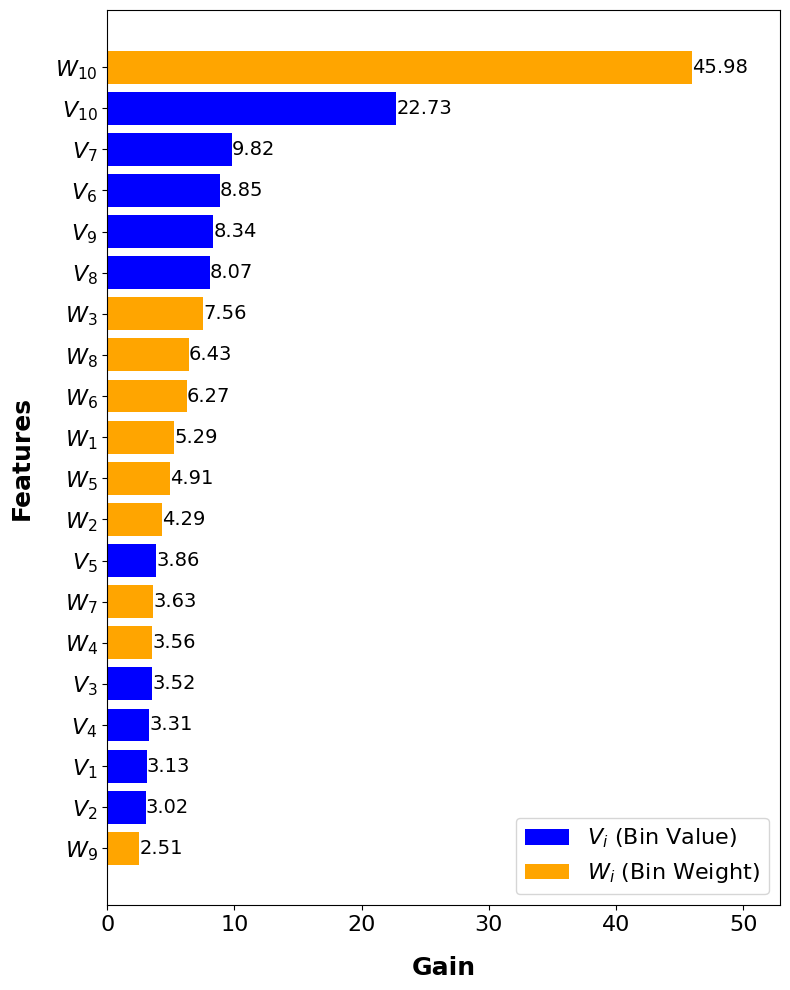

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from xgboost import XGBClassifier
from matplotlib.patches import Patch

# Load Dataset
INPUT = "/content/drive/MyDrive/research/dataset2_αβ.csv"
df = pd.read_csv(INPUT)

TARGET_COL = "final_result"

drop_cols = [c for c in ["id_student","code_module","code_presentation","VLE_normalized"] if c in df.columns]
df = df.drop(columns=drop_cols)

# Train/Test Split
idx = np.arange(len(df))

train_idx, test_idx = train_test_split(
    idx,
    test_size=0.2,
    random_state=42,
    stratify=df[TARGET_COL]
)


# Feature Selection (CP10)
BASE_DROP = {TARGET_COL}

def columns_for_checkpoint(k):

    secured = [f"V_{i}" for i in range(1,k+1) if f"V_{i}" in df.columns]
    assigned = [f"W_{i}" for i in range(1,k+1) if f"W_{i}" in df.columns]

    all_grade_cols = [c for c in df.columns if c.startswith("V_") or c.startswith("W_")]

    keep_non_grade = [c for c in df.columns if c not in BASE_DROP and c not in all_grade_cols]

    return keep_non_grade + secured + assigned


feat_cols = columns_for_checkpoint(10)

X = df[feat_cols]
y = df[TARGET_COL].astype(int)

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Preprocessing
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

numeric_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer([
    ("num", numeric_tf, num_cols),
    ("cat", categorical_tf, cat_cols)
])

# Train XGBoost
xgb = XGBClassifier(
    n_estimators=600,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", xgb)
])

pipe.fit(X_train, y_train)


# Extract Feature Importance
booster = pipe.named_steps["model"].get_booster()

# Count how many times each feature was used in splits
fcount = booster.get_score(importance_type="weight")
print("Number of splits per feature:", fcount)

feature_names = pipe.named_steps["preprocess"].get_feature_names_out()
fcount_named = {feature_names[int(k[1:])]: v for k, v in fcount.items()}
for f, c in fcount_named.items():
    print(f"{f}: {c}")

importance = booster.get_score(importance_type="gain")

feature_names = pipe.named_steps["preprocess"].get_feature_names_out()

importance_df = pd.DataFrame({
    "feature_index": list(importance.keys()),
    "gain": list(importance.values())
})

importance_df["feature_index"] = importance_df["feature_index"].str.replace("f","").astype(int)
importance_df["feature"] = importance_df["feature_index"].apply(lambda x: feature_names[x])

importance_df["feature"] = importance_df["feature"].str.replace("num__", "")
importance_df["feature"] = importance_df["feature"].str.replace("cat__", "")

# Keep only V_i and W_i features
importance_df = importance_df[
    importance_df["feature"].str.contains("V_|W_")
]

importance_df["feature"] = importance_df["feature"].str.replace("secured_g","V_")
importance_df["feature"] = importance_df["feature"].str.replace("assigned_g","W_")

# Ensure all 20 bars exist
expected_features = []

for i in range(1,11):
    expected_features.append(f"V_{i}")
    expected_features.append(f"W_{i}")

full_df = pd.DataFrame({"feature": expected_features})

importance_df = full_df.merge(
    importance_df[["feature","gain"]],
    on="feature",
    how="left"
)

importance_df["gain"] = importance_df["gain"].fillna(0)

# Sort by Gain
importance_df = importance_df.sort_values("gain",ascending=False)

plot_df = importance_df.iloc[::-1]

# Convert labels to LaTeX subscripts
def latex_label(f):

    if "V_" in f:
        return f"$V_{{{f.split('_')[1]}}}$"
    else:
        return f"$W_{{{f.split('_')[1]}}}$"

labels = [latex_label(f) for f in plot_df["feature"]]


# Colors
colors = ["blue" if "V_" in f else "orange" for f in plot_df["feature"]]


# Plot
plt.figure(figsize=(8,10))

bars = plt.barh(labels, plot_df["gain"], color=colors)


for i,v in enumerate(plot_df["gain"]):
    plt.text(v, i, f"{v:.2f}", va="center", fontsize=14)

max_gain = plot_df["gain"].max()
plt.xlim(0, max_gain * 1.15)

plt.xlabel("Gain", fontsize=18, fontweight="bold", labelpad=15)
plt.ylabel("Features", fontsize=18, fontweight="bold", labelpad=15)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

legend_elements = [
    Patch(facecolor='blue', label=r"$V_i$ (Bin Value)"),
    Patch(facecolor='orange', label=r"$W_i$ (Bin Weight)")
]

plt.legend(
    handles=legend_elements,
    loc="lower right",
    fontsize=16,
    frameon=True
)


plt.tight_layout()

SAVE_DIR = "/content/plots"
os.makedirs(SAVE_DIR,exist_ok=True)

plt.savefig(
    f"{SAVE_DIR}/Figure2_FeatureImportance_CP10.eps",
    format="eps",
    dpi=300
)

plt.show()